In [18]:
#This notebook includes the import of csv file and then use only the necessary columns
#some cleaning is also done like removing country codes
import pandas as pd

df = pd.read_csv("sportsref_download-2.csv")

df = df[['Home', 'Away', 'Score']].dropna()
df = df[df['Home'] != 'Home'].copy()

# Remove country codes
df['Home'] = df['Home'].str.rsplit(' ', n=1).str[0]
df['Away'] = df['Away'].str.split(' ', n=1).str[1]

df = df.replace({
    'USA': 'United States',
    'Bosnia–Herz': 'Bosnia and Herzegovina',
    'Korea Republic': 'South Korea',
    'IR Iran': 'Iran',
    'Congo DR': 'Democratic Republic of the Congo'
})

# Extract goals, excluding penalty shoot-out numbers
goals = df['Score'].str.extract(r'(\d+)[–-](\d+)').astype(int)
df['Goal_Difference'] = goals[0] - goals[1]

df = df[['Home', 'Away', 'Goal_Difference']]
df.to_csv('match_teams_goal_difference.csv', index=False)

df.head()

,Home,Away,Goal_Difference
0,Mexico,South Africa,2
1,South Korea,Czechia,1
2,Canada,Bosnia and Herzegovina,0
3,United States,Paraguay,3
4,Qatar,Switzerland,0


In [1]:
#2025 international games were taken manually from "https://inside.fifa.com/data-centre/teams/cabo-verde?year=2025" website
#from that website, total matches, wins, draws, defeats, goal scored, goal conceded were taken

import pandas as pd

teams = pd.read_excel("2025_games.xlsx")
#calculation of variables
teams["Win_Rate"] = teams["Wins"] / teams["Total matches"]
teams["Draw_Rate"] = teams["Draws"] / teams["Total matches"]
teams["Avg_Scored"] = teams["Goals scored"] / teams["Total matches"]
teams["Avg_Conceded"] = teams["Goals conceded"] / teams["Total matches"]

teams.to_csv("country_variables_2025.csv", index=False)

teams.head()

,Team,Total matches,Wins,Draws,Defeats,Goals scored,Goals conceded,Win_Rate,Draw_Rate,Avg_Scored,Avg_Conceded
0,Algeria,24,15,8,1,50,15,0.625000,0.333333,2.083333,0.625000
1,Argentina,9,7,1,1,19,3,0.777778,0.111111,2.111111,0.333333
2,Australia,10,7,0,3,16,9,0.700000,0.000000,1.600000,0.900000
3,Austria,10,6,2,2,23,7,0.600000,0.200000,2.300000,0.700000
4,Belgium,10,6,3,1,33,10,0.600000,0.300000,3.300000,1.000000


In [2]:
#adding different explanatory variables in the main dataset
import pandas as pd

matches = pd.read_csv("dataset.csv")
teams = pd.read_csv("country_variables_2025.csv").set_index("Team")

variables = {
    "Total matches": "Matches_Played_Difference",
    "Win_Rate": "Win_Rate_Difference",
    "Draw_Rate": "Draw_Rate_Difference",
    "Avg_Scored": "Avg_Scored_Difference",
    "Avg_Conceded": "Avg_Conceded_Difference"
}

for variable, column in variables.items():
    home = matches["Home"].map(teams[variable])
    away = matches["Away"].map(teams[variable])

    if home.isna().any() or away.isna().any():
        raise ValueError("Check that team names match in both files.")

    matches[column] = home - away

goal_difference = matches.pop("Goal_Difference")
matches["Goal_Difference"] = goal_difference

matches.to_csv("dataset.csv", index=False, float_format="%.4f")

matches.head()

,Home,Away,FIFA_Points_Difference,Matches_Played_Difference,Win_Rate_Difference,Draw_Rate_Difference,Avg_Scored_Difference,Avg_Conceded_Difference,Goal_Difference
0,Mexico,South Africa,259.10,-4,0.000000,-0.037500,-0.237500,0.212500,2
1,South Korea,Czechia,85.89,3,0.015385,0.030769,-0.307692,-0.130769,1
2,Canada,Bosnia and Herzegovina,172.26,4,-0.100000,0.157143,-0.628571,-0.428571,0
3,United States,Paraguay,165.88,8,0.155556,-0.188889,0.733333,0.222222,3
4,Qatar,Switzerland,-199.75,1,-0.427273,-0.027273,-1.418182,1.127273,0


In [4]:
#this is the data from the fbref where player played in top 5 league
#if the team doesnot have a player in top 5 league, it returns 0
import pandas as pd

players = {
    "Algeria": 11, "Argentina": 21, "Australia": 5,
    "Austria": 17, "Belgium": 20, "Bosnia and Herzegovina": 6,
    "Brazil": 15, "Cabo Verde": 1, "Canada": 9,
    "Colombia": 8, "Croatia": 17, "Curaçao": 0,
    "Czechia": 7, "Côte d'Ivoire": 13,
    "Democratic Republic of the Congo": 10,
    "Ecuador": 6, "Egypt": 4, "England": 26,
    "France": 24, "Germany": 26, "Ghana": 12,
    "Haiti": 4, "Iran": 0, "Iraq": 0,
    "Japan": 13, "Jordan": 1, "Mexico": 6,
    "Morocco": 17, "Netherlands": 23, "New Zealand": 1,
    "Norway": 17, "Panama": 0, "Paraguay": 4,
    "Portugal": 17, "Qatar": 0, "Saudi Arabia": 1,
    "Scotland": 12, "Senegal": 20, "South Africa": 1,
    "South Korea": 5, "Spain": 26, "Sweden": 15,
    "Switzerland": 23, "Tunisia": 7, "Türkiye": 9,
    "United States": 13, "Uruguay": 8, "Uzbekistan": 1
}

matches = pd.read_csv("dataset.csv")

home = matches["Home"].str.strip().map(players)
away = matches["Away"].str.strip().map(players)

if home.isna().any() or away.isna().any():
    raise ValueError("Some team names do not match. Check their spelling.")

matches["Top_5_League_Players_Difference"] = home - away

# Keep goal difference last.
goal_difference = matches.pop("Goal_Difference")
matches["Goal_Difference"] = goal_difference

matches.to_csv("dataset.csv", index=False, float_format="%.4f")

matches.head()

,Home,Away,FIFA_Points_Difference,Matches_Played_Difference,Win_Rate_Difference,Draw_Rate_Difference,Avg_Scored_Difference,Avg_Conceded_Difference,Top_5_League_Players_Difference,Goal_Difference
0,Mexico,South Africa,259.10,-4,0.0000,-0.0375,-0.2375,0.2125,5,2
1,South Korea,Czechia,85.89,3,0.0154,0.0308,-0.3077,-0.1308,-2,1
2,Canada,Bosnia and Herzegovina,172.26,4,-0.1000,0.1571,-0.6286,-0.4286,3,0
3,United States,Paraguay,165.88,8,0.1556,-0.1889,0.7333,0.2222,9,3
4,Qatar,Switzerland,-199.75,1,-0.4273,-0.0273,-1.4182,1.1273,-23,0


In [7]:
#using data from Linear regression 2.2 file
import pandas as pd

matches = pd.read_csv("dataset.csv")

other = pd.read_csv(
    "../Linear_Regression_2.2/data/data2.2.csv"
)

print(other.columns.tolist())
print(other.head())

['Team', 'Opponent', 'FIFA points', 'Opp FIFA points', 'Avg Scored', 'Opp Avg Conceded', 'Rest Days', 'Last 5 Avg Scored', 'Last 5 Opp Avg Conceded', 'Win Rate', 'Goals']
             Team      Opponent  FIFA points  Opp FIFA points  Avg Scored  \
0          Mexico  South Africa      1687.48          1428.38    1.450000   
1  Korea Republic       Czechia      1591.63          1505.74    1.500000   
2          Canada   Bosnia-Herz      1559.48          1387.22    1.500000   
3             USA      Paraguay      1671.23          1505.35    1.937500   
4           Qatar   Switzerland      1450.31          1650.06    0.818182   

   Opp Avg Conceded  Rest Days  Last 5 Avg Scored  Last 5 Opp Avg Conceded  \
0          0.846154          7                1.8                      1.0   
1          0.900000          8                1.4                      1.2   
2          1.000000          7                1.4                      0.8   
3          1.000000          6                2.2     

In [8]:
#using last 5 avg scored and Last 5 opp avvg conceded
aliases = {
    "Korea Republic": "South Korea",
    "USA": "United States",
    "Bosnia-Herz": "Bosnia and Herzegovina",
    "IR Iran": "Iran",
    "Congo DR": "Democratic Republic of the Congo"
}

data = other[
    ["Team", "Opponent", "Last 5 Avg Scored", "Last 5 Opp Avg Conceded"]
].copy()

data = data.rename(columns={"Team": "Home", "Opponent": "Away"})

for column in ["Home", "Away"]:
    data[column] = data[column].str.strip().replace(aliases)

columns = ["Last 5 Avg Scored", "Last 5 Opp Avg Conceded"]
matches = matches.drop(columns=columns, errors="ignore")

matches = matches.merge(
    data, on=["Home", "Away"], how="left", validate="many_to_one"
)

if matches[columns].isna().any().any():
    raise ValueError("Some team names did not match.")

matches.to_csv("dataset.csv", index=False, float_format="%.4f")

In [9]:
#loading data
#X has all the 8 explanatory variables
#Y has the predictive value
import pandas as pd

data = pd.read_csv("dataset.csv")

X = data.drop(columns=["Home", "Away", "Goal_Difference"])
y = data["Goal_Difference"]

print("Matches:", len(data))
print("Explanatory variables:", X.shape[1])
print("Missing values:", data.isna().sum().sum())

data.head()

Matches: 104
Explanatory variables: 8
Missing values: 0


,Home,Away,Matches_Played_Difference,Win_Rate_Difference,Draw_Rate_Difference,Avg_Scored_Difference,Avg_Conceded_Difference,Top_5_League_Players_Difference,Last 5 Avg Scored,Last 5 Opp Avg Conceded,Goal_Difference
0,Mexico,South Africa,-4,0.0000,-0.0375,-0.2375,0.2125,5,1.8,1.0,2
1,South Korea,Czechia,3,0.0154,0.0308,-0.3077,-0.1308,-2,1.4,1.2,1
2,Canada,Bosnia and Herzegovina,4,-0.1000,0.1571,-0.6286,-0.4286,3,1.4,0.8,0
3,United States,Paraguay,8,0.1556,-0.1889,0.7333,0.2222,9,2.2,1.0,3
4,Qatar,Switzerland,1,-0.4273,-0.0273,-1.4182,1.1273,-23,0.2,1.4,0


In [11]:
#data split into training and testing set
#70% training and 30% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

print("Training matches:", len(X_train))
print("Testing matches:", len(X_test))

Training matches: 72
Testing matches: 32


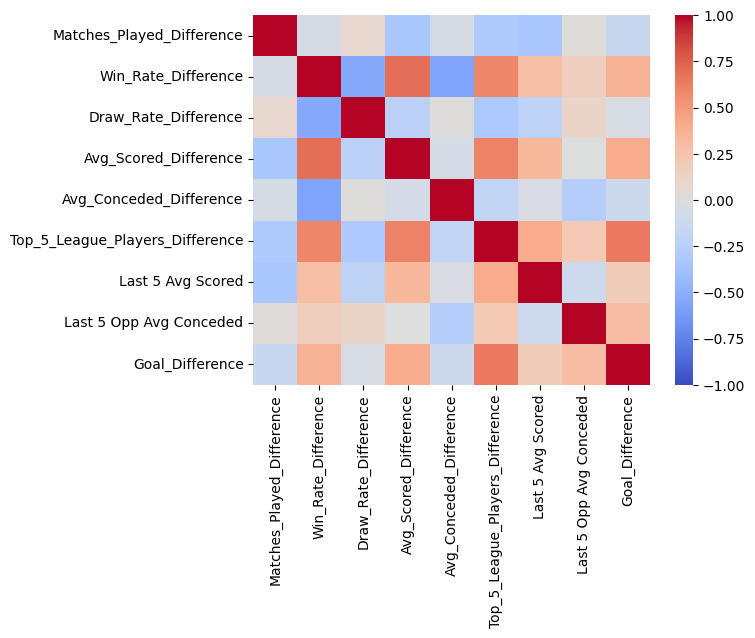

In [21]:
#displaying the correlation between predictors and goal difference
#using training data to find out strong related variables
import matplotlib.pyplot as plt
import seaborn as sns

training_data = X_train.copy()
training_data["Goal_Difference"] = y_train

sns.heatmap(training_data.corr(),
            cmap="coolwarm",
            vmin=-1,
            vmax=1)

plt.show()

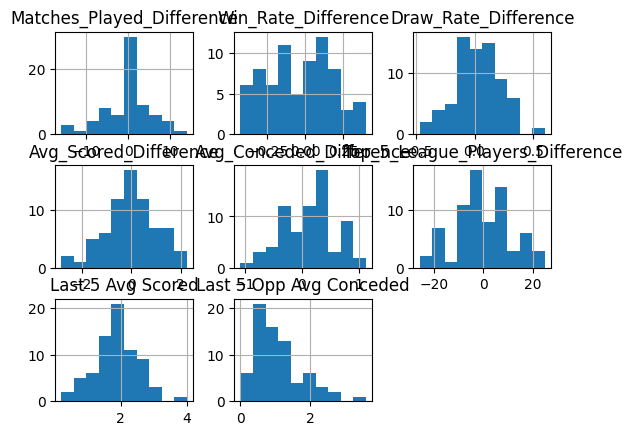

In [15]:
#identify skewed distribution
X_train.hist()
plt.show()